# Experiment 5 — QELM and QRC on Real Data

## Overview

This experiment validates the diagnostic framework on **real-world tasks**, testing whether the three diagnostics (\(\Lambda\), \(R_{\mathrm{eff}}\), \(\mathrm{Var}_x\)) generalise beyond synthetic benchmarks.

Two tasks are studied:
1. **QELM on LiH** — predict excited-state energies from ground-state wavefunctions (quantum chemistry).
2. **QRC on weather data** — predict daily temperature from past meteorological variables (time-series).

The hypothesis is that circuit families with high \(\Lambda\) and high \(R_{\mathrm{eff}}\) perform better on both tasks, confirming the framework's predictive power on real data.

## Part 1: QELM on LiH Excited-State Energy Prediction

A **Quantum Extreme Learning Machine (QELM)** uses the quantum circuit as a fixed feature map — no temporal feedback, no circuit training.

**Dataset**: LiH molecular wavefunctions at varying bond lengths.
**Task**: predict the first excited-state energy (\(E_1\)) from the ground-state amplitudes.
**Encoding**: amplitude encoding (Ry rotations, \(\theta = 2\arcsin(a)\)) onto \(n_e\) encoding qubits.
**Readout**: Ridge regression on \(k\)-local Pauli observable expectations.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Sklearn imports

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from QELM import QuantumCircQiskit

from tqdm import tqdm 
from metrics import (
    lorentz_curves,
    order_statistics_score,
    renyi2_entropy,
)

In [2]:
with open('data/LiH/spectrums_LiH.npy', 'rb') as f:
            spectrums = np.load(f)
with open('data/LiH/bond_lengths_LiH.npy', 'rb') as f:
            bond_lengths = np.load(f)
with open('data/LiH/ground_states_LiH.npy', 'rb') as f:
            ground_states = np.load(f)

print("Spectrums shape:", spectrums.shape)
print("Bond lengths shape:", bond_lengths.shape)
print("Ground states shape:", ground_states.shape)

Spectrums shape: (300, 5)
Bond lengths shape: (300,)
Ground states shape: (300, 256)


### Single-Run QELM Example

A single QELM run on the LiH data to establish the baseline protocol: encode one ground state, run through the reservoir, collect observables, train Ridge readout, evaluate MSE and visualise predictions vs exact values.

In [3]:
# Run circuit for all values of ground states:
gate_set = 'Haar'#'D2_random_XZY'
num_gates = 500
nshots = 2000
nqbits = int(np.log2(ground_states.shape[1])) 
observables_type = [1]
obs_res = []
num_states =ground_states.shape[0]
qrc = QuantumCircQiskit(gate_set, nqbits = nqbits, degree=6, n_layers=1,observables_type = observables_type, nshots=nshots)

for i in range(num_states):
    res = qrc.run_circuit(ground_states[i])
    obs_res.append(res)
obs_res = np.array(obs_res)    

In [4]:
num_states =ground_states.shape[0]
y = np.zeros((num_states, 2))
y[:,0] = spectrums[:,1] - spectrums[:,0]
y[:,1] = spectrums[:,2] - spectrums[:,0]


X_train, X_test, y_train, y_test, bond_lengths_train, bond_lengths_test = train_test_split( 
obs_res, y, bond_lengths, test_size=0.33, random_state=42)

In [5]:
scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train)
y_test_scaled = scaler.transform(y_test)

In [6]:
lm = Ridge(alpha=1e-12)
lm.fit(X_train, y_train_scaled)

Ridge(alpha=1e-12)

Mean Squared Error:  1.1597262498171225e-07


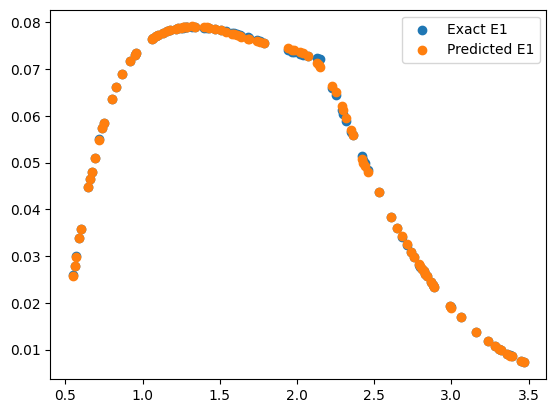

In [7]:
y_hat = lm.predict(X_test)
y_hat = scaler.inverse_transform(y_hat)

mse = np.mean(np.square(y_hat - y_test))
print('Mean Squared Error: ', mse)

plt.scatter(bond_lengths_test,y_test[:,0], label='Exact E1', marker='o')
plt.scatter(bond_lengths_test, y_hat[:,0], label='Predicted E1', marker='o')
plt.legend()
plt.show()

## QELM Sweep Results — All Families

Load the pre-computed QELM results for all circuit families and gate depths. Each configuration is a (family, num_gates) pair; results are stored as numpy arrays with MSE across `ns` random circuit instances.

In [10]:
import os

LOAD_QRC = True                            # set False to recompute from scratch
QRC_DIR  = os.path.join("results", "qelm", "chemistry", "LiH") 

# ── Experiment config ────────────────────────────────────────────────────────
nqbits_exp = int(np.log2(ground_states.shape[1]))  # log2(ground_states.shape[1]) = log2(256)
nqbits = nqbits_exp # log2(ground_states.shape[1]) = log2(256)
n_shadows = 10000   # number of classical shadows to estimate Renyi-2 entropy
K  =10
ns         = 100    # number of independent random reservoir instances per config
alpha_exp  = 1e-7  # Ridge regularisation (same as existing cells above)

# ── Persistence helpers ──────────────────────────────────────────────────────
def _qrc_path(gates_name, nqbits, ns, depth=None, degree=None,
              n_layers=None, scrambler_depth=None):
    tag = gates_name
    if degree          is not None: tag += f"_deg{degree}"
    if depth           is not None: tag += f"_depth{depth}"
    if n_layers        is not None: tag += f"_L{n_layers}"
    if scrambler_depth is not None: tag += f"_K{scrambler_depth}"
    return os.path.join(QRC_DIR, f"{tag}_{nqbits}q_{ns}runs.npz")
def _load_qrc(path):
    d = np.load(path)
    return d["obs_res_all"], d["y_hat_all"], d["mse_all"], d["ors"], d["delta_s"], d["var_x"]

In [22]:
path = _qrc_path("Haar", nqbits_exp, ns)
print(f"Loading Haar  ← {path}")
obs, y_hat, mse, ors, delta_s, var_x  = _load_qrc(path)
results_Haar = {"obs_res": obs, "y_hat": y_hat, "mse": mse, "ors": ors, "delta_s": delta_s, "var_x": var_x}
print(f"  MSE = {np.mean(mse):.8f} ± {np.std(mse):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

# ── D2_random: sweep expected degree of Erdős–Rényi graph ───────────────────
degrees = [1, 2, 4, 6, 8, 10, 14]
results_degree = {}

for deg in degrees:
    path = _qrc_path("D2_random", nqbits_exp, ns, degree=deg)
    print(f"Loading D2_random deg={deg}  ← {path}")
    obs, y_hat, mse, ors, delta_s, var_x  = _load_qrc(path)
    results_degree[deg] = {"obs_res": obs, "y_hat": y_hat, "mse": mse, "ors": ors, "delta_s": delta_s, "var_x": var_x}
    print(f"  deg={deg:2d}  MSE = {np.mean(mse):.8f} ± {np.std(mse):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

# ── D2_random_XZ: sweep expected degree of Erdős–Rényi graph ───────────────────
degrees = [1, 2, 4, 6, 8, 10, 14]
results_degree_XZ = {}

for deg in degrees:
    path = _qrc_path("D2_random_XZ", nqbits_exp, ns, degree=deg)
    print(f"Loading D2_random_XZ deg={deg}  ← {path}")
    obs, y_hat, mse, ors, delta_s, var_x  = _load_qrc(path)
    results_degree_XZ[deg] = {"obs_res": obs, "y_hat": y_hat, "mse": mse, "ors": ors, "delta_s": delta_s, "var_x": var_x}
    print(f"  deg={deg:2d}  MSE = {np.mean(mse):.8f} ± {np.std(mse):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

# ── D2_random_XZY: sweep expected degree of Erdős–Rényi graph ───────────────────
degrees = [1, 2, 4, 6, 8, 10, 14]
results_degree_XZY = {}

for deg in degrees:
    path = _qrc_path("D2_random_XZY", nqbits_exp, ns, degree=deg)
    print(f"Loading D2_random_XZY deg={deg}  ← {path}")
    obs, y_hat, mse, ors, delta_s, var_x  = _load_qrc(path)
    results_degree_XZY[deg] = {"obs_res": obs, "y_hat": y_hat, "mse": mse, "ors": ors, "delta_s": delta_s, "var_x": var_x}
    print(f"  deg={deg:2d}  MSE = {np.mean(mse):.8f} ± {np.std(mse):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

# ── G1/G2/G3: sweep number of gates (circuit depth) ─────────────────────────
depths     = [5, 10, 50, 100, 500, 1000]
g_families = ["G1", "G2", "G3"]
results_depth = {f: {} for f in g_families}

for family in g_families:
    for depth in depths:
        path = _qrc_path(family, nqbits_exp, ns, depth=depth)
        print(f"Loading {family} depth={depth}  ← {path}")
        obs, y_hat, mse, ors, delta_s, var_x  = _load_qrc(path)
        ors[ors<-254] = -254
        results_depth[family][depth] = {"obs_res": obs, "y_hat": y_hat, "mse": mse, "ors": ors, "delta_s": delta_s, "var_x": var_x}
        print(f"  {family} depth={depth:4d}  MSE = {np.mean(mse):.8f} ± {np.std(mse):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

Loading Haar  ← results\qelm\chemistry\LiH\Haar_8q_100runs.npz
  MSE = 0.00000012 ± 0.00000000, ORS = 8.5489 ± 0.0000, ΔS = -0.0028 ± 0.0204, Var(X) = 0.0189 ± 0.0116
Loading D2_random deg=1  ← results\qelm\chemistry\LiH\D2_random_deg1_8q_100runs.npz
  deg= 1  MSE = 0.00006425 ± 0.00001940, ORS = -53.2618 ± 39.3960, ΔS = 0.8486 ± 0.3982, Var(X) = 0.0322 ± 0.0533
Loading D2_random deg=2  ← results\qelm\chemistry\LiH\D2_random_deg2_8q_100runs.npz
  deg= 2  MSE = 0.00004116 ± 0.00002035, ORS = -18.5899 ± 26.6450, ΔS = 0.5637 ± 0.3806, Var(X) = 0.0236 ± 0.0422
Loading D2_random deg=4  ← results\qelm\chemistry\LiH\D2_random_deg4_8q_100runs.npz
  deg= 4  MSE = 0.00001417 ± 0.00001647, ORS = 3.0320 ± 15.2254, ΔS = 0.1705 ± 0.2410, Var(X) = 0.0141 ± 0.0252
Loading D2_random deg=6  ← results\qelm\chemistry\LiH\D2_random_deg6_8q_100runs.npz
  deg= 6  MSE = 0.00000777 ± 0.00000942, ORS = 10.6503 ± 4.4103, ΔS = 0.0281 ± 0.1168, Var(X) = 0.0097 ± 0.0185
Loading D2_random deg=8  ← results\qelm\chemi

Haar R_eff = 2.2
G1: R_eff = ['1', '1', '1', '1', '1', '1']
G2: R_eff = ['1', '1', '1', '1', '1', '1']
G3: R_eff = ['1', '1', '1', '2', '2', '2']
D2_random: R_eff = ['1.29', '1.36', '1.63', '1.80', '1.87', '1.93', '1.86']
D2_random_XZ: R_eff = ['1.35', '1.62', '1.97', '2.09', '2.15', '2.16', '2.12']
D2_random_XZY: R_eff = ['1.47', '1.81', '2.13', '2.17', '2.13', '2.15', '2.18']


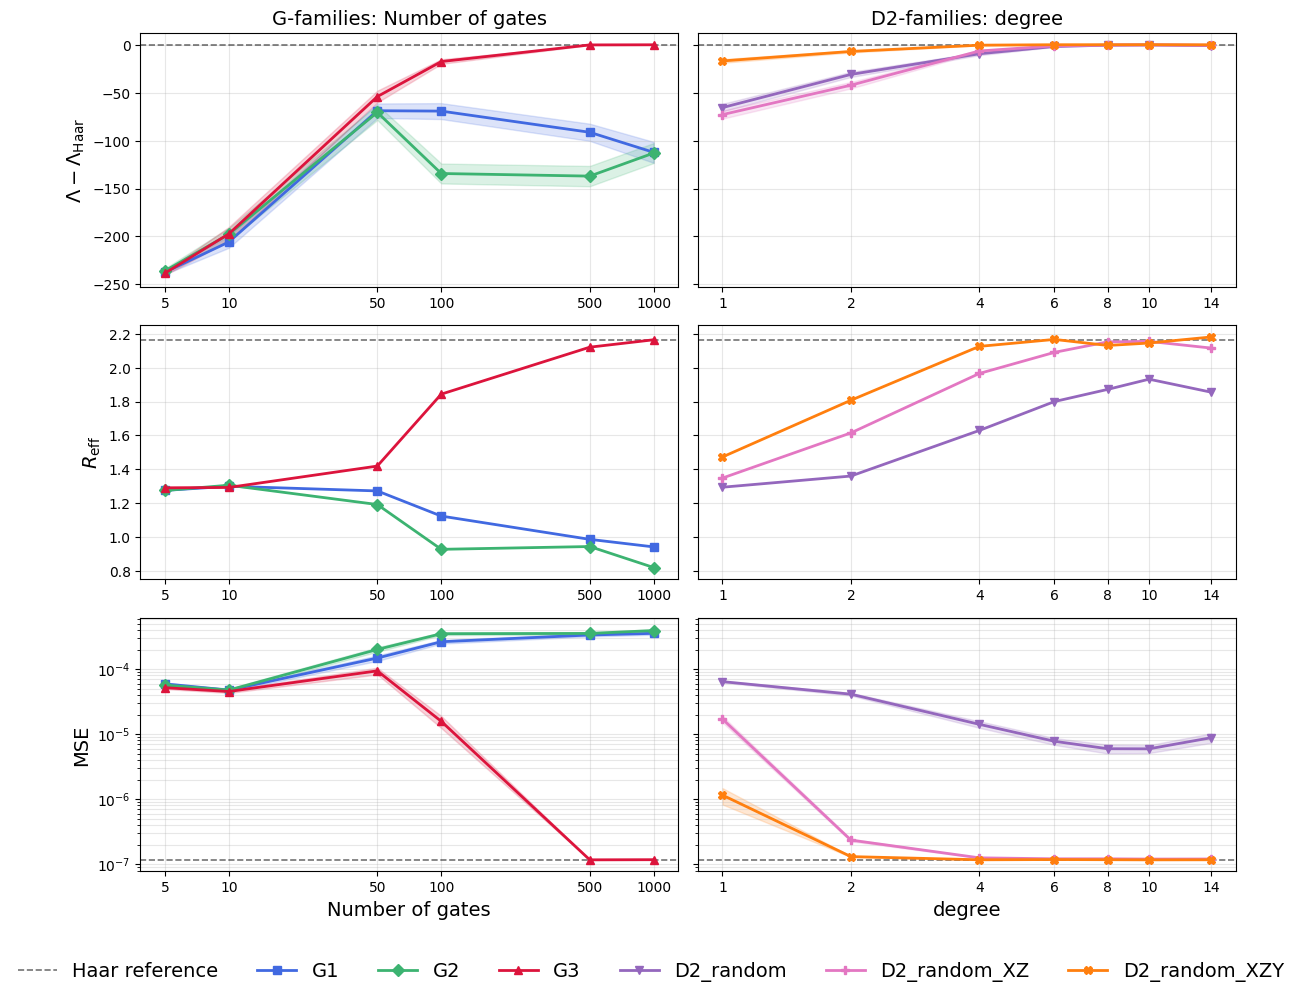

In [24]:
from matplotlib.ticker import ScalarFormatter, NullLocator

ors_Haar = np.load('results/ors/Haar_100runs.npz')
ors_Haar8 = ors_Haar['lambda_haar_n8'][1]

# ─────────────────────────────────────────────────────────────────────
# CELL A — R_eff helper, applied to obs_res
# ─────────────────────────────────────────────────────────────────────
def effective_rank(F, eps=1e-12):
    """Participation ratio of singular values of the centred feature matrix."""
    F = F - F.mean(axis=0, keepdims=True)
    try:
        sv = np.linalg.svd(F, compute_uv=False)
    except np.linalg.LinAlgError:
        from scipy.linalg import svd
        sv = svd(F, compute_uv=False, lapack_driver='gesvd')
    sv = sv[sv > eps]
    if len(sv) == 0:
        return 0.0
    return float(sv.sum() ** 2 / (sv ** 2).sum())


def add_R_eff(res):
    """
    Compute R_eff from obs_res. obs_res may have shape (ns, T, n_obs)
    (per-sample reservoir trajectories) or (T, n_obs). We average R_eff
    over samples if the leading axis is a seed dimension.
    """
    if 'R_eff' in res:
        return res
    X = np.asarray(res['obs_res'])
    if X.ndim == 3:
        # (ns, T, n_obs): one R_eff per sample, then average
        reffs = [effective_rank(X[i]) for i in range(X.shape[0])]
        res['R_eff']     = float(np.mean(reffs))
        res['R_eff_sem'] = float(np.std(reffs) / np.sqrt(len(reffs))) if len(reffs) > 1 else 0.0
    else:
        res['R_eff']     = effective_rank(X)
        res['R_eff_sem'] = 0.0
    return res


# Augment all loaded dicts
add_R_eff(results_Haar)
for family in g_families:
    for depth in results_depth[family]:
        add_R_eff(results_depth[family][depth])
for deg in results_degree:
    add_R_eff(results_degree[deg])
for deg in results_degree_XZ:
    add_R_eff(results_degree_XZ[deg])
for deg in results_degree_XZY:
    add_R_eff(results_degree_XZY[deg])

print(f"Haar R_eff = {results_Haar['R_eff']:.1f}")
for family in g_families:
    rs = [results_depth[family][d]['R_eff'] for d in sorted(results_depth[family])]
    print(f"{family}: R_eff = {[f'{r:.0f}' for r in rs]}")
for name, dct in [('D2_random', results_degree),
                  ('D2_random_XZ', results_degree_XZ),
                  ('D2_random_XZY', results_degree_XZY)]:
    rs = [dct[d]['R_eff'] for d in sorted(dct)]
    print(f"{name}: R_eff = {[f'{r:.2f}' for r in rs]}")


# ─────────────────────────────────────────────────────────────────────
# Style
# ─────────────────────────────────────────────────────────────────────
FAMILY_COLORS = {
    'Haar':          '#000000',
    'G1':            'royalblue',
    'G2':            'mediumseagreen',
    'G3':            'crimson',
    'D2_random':     '#9467bd',
    'D2_random_XZ':  '#e377c2',
    'D2_random_XZY': 'tab:orange',
}
FAMILY_MARKERS = {
    'Haar': 'o', 'G1': 's', 'G2': 'D', 'G3': '^',
    'D2_random': 'v', 'D2_random_XZ': 'P', 'D2_random_XZY': 'X',
}

ORS_LOWER_CAP = -254.0   # matches the clip you already apply on load
MSE_FLOOR     = 1e-15


# ─────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────
def _scalar_stats(res, key, clip_low=None):
    """Mean and SEM of a (ns,) array. Returns NaN if missing."""
    if key not in res:
        return np.nan, np.nan
    vals = np.asarray(res[key], dtype=float)
    if vals.ndim == 2:
        vals = vals[:, -1]
    if clip_low is not None:
        vals = np.clip(vals, clip_low, None)
    ns = len(vals)
    return float(np.mean(vals)), float(np.std(vals) / np.sqrt(ns)) if ns > 1 else 0.0


def _haar_scalar(metric_key, clip_low=None):
    if metric_key == 'R_eff':
        return results_Haar['R_eff']
    m, _ = _scalar_stats(results_Haar, metric_key, clip_low=clip_low)
    return m


def _collect(results_dict_for_family):
    """results_dict_for_family: {control_value: result_dict}"""
    cs = sorted(results_dict_for_family.keys())
    ors_m, ors_s, reff, mse_m, mse_s = [], [], [], [], []
    for c in cs:
        r = results_dict_for_family[c]
        m, s = _scalar_stats(r, 'ors', clip_low=ORS_LOWER_CAP)
        ors_m.append(m); ors_s.append(s)
        reff.append(r['R_eff'])
        m, s = _scalar_stats(r, 'mse', clip_low=MSE_FLOOR)
        mse_m.append(m); mse_s.append(s)
    return (np.array(cs), np.array(ors_m), np.array(ors_s),
            np.array(reff), np.array(mse_m), np.array(mse_s))


# ─────────────────────────────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────────────────────────────
def fig2_qrc(save_path=None,
             ors_cap=ORS_LOWER_CAP, mse_floor=MSE_FLOOR):
    if save_path is None:
        save_path = f'fig2_qrc_n{nqbits_exp}.png'

    fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey='row')

    g_target = ['G1', 'G2', 'G3']
    g_data  = {fam: _collect(results_depth[fam]) for fam in g_target}
    d2_data = {
        'D2_random':     _collect(results_degree),
        'D2_random_XZ':  _collect(results_degree_XZ),
        'D2_random_XZY': _collect(results_degree_XZY),
    }

    metrics = [
        ('ors',   r'$\Lambda- \Lambda_{\rm Haar}$'),
        ('R_eff', r'$R_{\rm eff}$'),
        ('mse',   'MSE'),
    ]

    for row, (key, ylabel) in enumerate(metrics):
        for col in range(2):
            ax = axes[row, col]

            # Haar reference
            clip_low = ors_cap if key == 'ors' else (mse_floor if key == 'mse' else None)
            href = _haar_scalar(key, clip_low=clip_low) if key!='ors' else 0
            if href is not None and not np.isnan(href):
                ax.axhline(href, color=FAMILY_COLORS['Haar'],
                           ls='--', alpha=0.55, lw=1.2,
                           label='Haar reference' if (row == 0 and col == 0) else None)

            families = g_target if col == 0 else list(d2_data.keys())
            data_src = g_data   if col == 0 else d2_data

            cs_max = None
            for family in families:
                color  = FAMILY_COLORS.get(family, '#888')
                marker = FAMILY_MARKERS.get(family, 'o')
                cs, ors_m, ors_s, reff, mse_m, mse_s = data_src[family]
                if len(cs) == 0:
                    continue
                cs_max = cs

                if key == 'ors':
                    ors_m = ors_m - ors_Haar8
                    ax.plot(cs, ors_m, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                    ax.fill_between(cs, ors_m - ors_s, ors_m + ors_s,
                                    color=color, alpha=0.18)
                elif key == 'R_eff':
                    ax.plot(cs, reff, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                else:  # mse
                    ax.plot(cs, mse_m, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                    ax.fill_between(cs, mse_m - mse_s, mse_m + mse_s,
                                    color=color, alpha=0.18)

            ax.set_xscale('log')
            if key == 'mse':
                ax.set_yscale('log')

            ax.grid(True, which='both', alpha=0.3)

            if cs_max is not None:
                ax.set_xticks(cs_max)
                ax.get_xaxis().set_major_formatter(ScalarFormatter())
                ax.get_xaxis().set_minor_locator(NullLocator())

            if row == 0:
                ax.set_title('G-families: Number of gates' if col == 0
                             else 'D2-families: degree', fontsize=14)
            if row == 2:
                ax.set_xlabel('Number of gates' if col == 0 else 'degree',
                              fontsize=14)
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=14)

    # Optional: log-scale MSE if dynamic range is wide
    # axes[2, 0].set_yscale('log'); axes[2, 1].set_yscale('log')

    handles, labels = [], []
    for ax in axes[0]:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh); labels.append(ll)
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, -0.01), ncol=len(labels),
               fontsize=14, frameon=False)

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()


fig2_qrc()

## Part 2: QRC on EMSIG Energy Data

Intermediate validation task: **EMSIG electricity market time-series** prediction.

The EMSIG dataset contains hourly energy market prices. This section applies the same QRC pipeline (encoding → reservoir → Ridge readout) to check whether the framework generalises to financial/energy time-series before moving to the full weather experiment.

In [25]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import pandas as pd
from QRC import QuantumRC_Circuit
from sklearn.metrics import mean_absolute_error

# ─────────────────────────────────────────────────────────────────────
# EMSIG loader for the Brücke et al. (2024) energy demand benchmark
# Predicts _sum_consumption_active_power for EMS 3/4/5 (2019–2020)
# Cadence: 15 min  →  4 steps/hour, 96 steps/day, 672 steps/week
# Units in the file are WATTS; divide by 1000 for kW.
# ─────────────────────────────────────────────────────────────────────

CSV_PATH = "data/time_series//emsig_energy_data_by_ems.csv"
TARGET   = "_sum_consumption_active_power"

def effective_rank(F, eps=1e-12):
    """Participation ratio of singular values of the centred feature matrix."""
    F = F - F.mean(axis=0, keepdims=True)
    try:
        sv = np.linalg.svd(F, compute_uv=False)
    except np.linalg.LinAlgError:
        from scipy.linalg import svd
        sv = svd(F, compute_uv=False, lapack_driver='gesvd')
    sv = sv[sv > eps]
    if len(sv) == 0:
        return 0.0
    return float(sv.sum() ** 2 / (sv ** 2).sum())


def load_ems_series(ems_id="ems_3",
                    start="2019-01-01",
                    end="2020-12-31 23:59:59",
                    resample="1h"):       # "15min" to keep native cadence
    df = pd.read_csv(CSV_PATH, usecols=["ems_id", "time", TARGET])
    df = df[df["ems_id"] == ems_id].copy()
    df["time"]  = pd.to_datetime(df["time"], unit="ms", utc=True)
    df[TARGET]  = pd.to_numeric(df[TARGET], errors="coerce")

    df = (df.sort_values("time")
            .set_index("time")[[TARGET]]
            .loc[start:end])

    # Regular 15-min grid, interpolate small gaps
    idx = pd.date_range(start, end, freq="15min", tz="UTC")
    df  = df.reindex(idx)
    df[TARGET] = df[TARGET].interpolate(method="time", limit=16)  # ≤4 h
    df = df.dropna()

    # Down-sample if requested
    if resample is not None:
        df = df.resample(resample).mean().dropna()

    return (df[TARGET].values / 1000.0).astype(float)        # → kW


# ── Build the autoregressive series for the QRC ──────────────────────────────
series = load_ems_series(ems_id="ems_3", resample="15min")
print(f"Full hourly series: {len(series)} samples "
      f"≈ {len(series)/24:.0f} days")

# Pick a tractable contiguous slice: ~8000 hourly steps = ~333 days
N = 5000
series = series[:N]

# Chronological split: 70/15/15 — matches your other experiments
n_train = int(0.70 * N)
n_val   = int(0.15 * N)
y_train = series[:n_train]
y_val   = series[n_train : n_train + n_val]
y_test  = series[n_train + n_val :]
print(f"train/val/test sizes: {len(y_train)}/{len(y_val)}/{len(y_test)}")

# Standardize on train only (avoid leakage)
scaler_y = MinMaxScaler((0,1))
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

y_pers1 = np.r_[y_val[-1], y_test[:-1]]

# Autoregressive mode: no exogenous X. Pass None (or zeros) for X_*_scaled.
X_train_scaled = None
X_val_scaled   = None
X_test_scaled  = None


# ── QRC ──────────────────────────────────────────────────────────────────────
t_dismiss = 100
qrc = QuantumRC_Circuit(
    nqbits=3, k_exp=1, encoding='pauli', num_gates=1000, gates_set='D2_random_XZY', n_layers = 1, degree=14,
    dim_y=1, input_mode='autoregressive', theta_scale=np.pi, observables_type = [1,2],
    alpha=1e-10, Nv=1, t_dismiss=t_dismiss, n_measure=4,
)

y_train_pred_qrc = qrc.train(y=y_train_scaled, scaler=scaler_y,
                             X_train_scaled=X_train_scaled)
y_val_pred_qrc   = qrc.test (y=y_val_scaled,   scaler=scaler_y,
                             X_test_scaled=X_val_scaled,  retrain=True)
y_test_pred_qrc  = qrc.test (y=y_test_scaled,  scaler=scaler_y,
                             X_test_scaled=X_test_scaled, retrain=True)
reffs = effective_rank(qrc.X_train)
print('Effective rank of the feature matrix:', reffs)

Full hourly series: 69781 samples ≈ 2908 days
train/val/test sizes: 3500/750/750
Effective rank of the feature matrix: 10.610032015145702


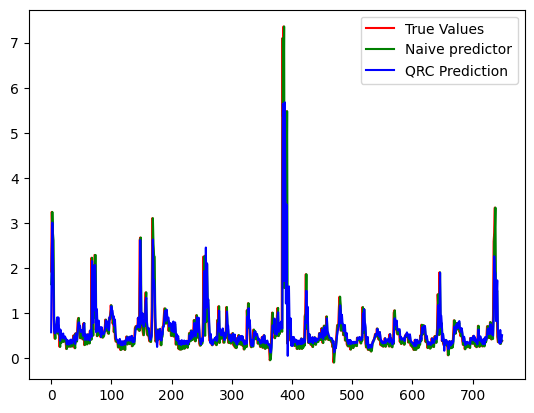

In [26]:
plt.plot(y_test, color='red', label='True Values')
plt.plot(y_pers1, color='green', label='Naive predictor')
plt.plot(y_test_pred_qrc, color= 'blue', label='QRC Prediction')
plt.legend()
plt.show()

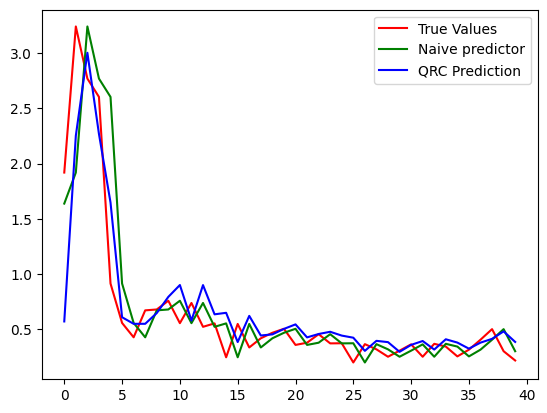

In [27]:
plt.plot(y_test[:40], color='red', label='True Values')
plt.plot(y_pers1[:40], color='green', label='Naive predictor')
plt.plot(y_test_pred_qrc[:40], color= 'blue', label='QRC Prediction')
plt.legend()
plt.show()

In [28]:
def metrics(y_true, y_pred, label=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err    = y_true - y_pred
    rmse   = np.sqrt(np.mean(err**2))
    mae    = np.mean(np.abs(err))
    nrmse  = rmse / (y_true.max() - y_true.min())
    mape   = np.mean(np.abs(err) / np.maximum(np.abs(y_true), 1e-6)) * 100
    r2     = 1 - np.sum(err**2) / np.sum((y_true - y_true.mean())**2)
    print(f"{label:>14}  RMSE={rmse:.4f}  MAE={mae:.4f}  "
          f"NRMSE={nrmse:.4f}  MAPE={mape:.1f}%  R²={r2:.3f}")
    return dict(rmse=rmse, mae=mae, nrmse=nrmse, mape=mape, r2=r2)

In [29]:
# 1) Constant predictor (train mean)
y_const = np.full_like(y_test, y_train.mean())

# 2) Naive persistence: ŷ_t = y_{t-1}
y_pers1 = np.r_[y_val[-1], y_test[:-1]]

# 3) Daily naive: ŷ_t = y_{t-24}  (same hour yesterday)
# need last 24 train points to seed
seed24  = y_val[-24:]
y_full  = np.r_[seed24, y_test]
y_pers24 = y_full[:-24][:len(y_test)]

# 4) Weekly naive: ŷ_t = y_{t-168} (same hour, same day last week)
seed168 = y_val[-168:]
y_full  = np.r_[seed168, y_test]
y_pers168 = y_full[:-168][:len(y_test)]

# 5) Linear AR(24) — your reservoir must beat this to claim nonlinearity helps
def make_ar_xy(s, p):
    X = np.stack([s[i:i+p] for i in range(len(s)-p)])
    y = s[p:]
    return X, y
p = 24
Xtr, ytr_ = make_ar_xy(y_train, p)
ar = Ridge(alpha=1e-3).fit(Xtr, ytr_)

# autoregressive rollout on test
hist = list(y_train[-p:])
y_ar = []
for _ in range(len(y_test)):
    pred = ar.predict(np.array(hist[-p:]).reshape(1,-1))[0]
    y_ar.append(pred)
    hist.append(pred)
y_ar = np.array(y_ar)

# Compute everything
metrics(y_test, y_const,            "const")
metrics(y_test, y_pers1,            "persist-1h")
metrics(y_test, y_pers24,           "persist-24h")
metrics(y_test, y_pers168,          "persist-1w")
metrics(y_test, y_ar,               "AR(24)")
metrics(y_test, y_test_pred_qrc,     "QRC")

         const  RMSE=0.6555  MAE=0.3948  NRMSE=0.0879  MAPE=109.0%  R²=-0.060
    persist-1h  RMSE=0.5380  MAE=0.2210  NRMSE=0.0721  MAPE=39.2%  R²=0.286
   persist-24h  RMSE=0.9031  MAE=0.4230  NRMSE=0.1211  MAPE=96.7%  R²=-1.012
    persist-1w  RMSE=0.8996  MAE=0.4243  NRMSE=0.1206  MAPE=97.8%  R²=-0.997
        AR(24)  RMSE=0.6593  MAE=0.3970  NRMSE=0.0884  MAPE=109.5%  R²=-0.073
           QRC  RMSE=0.4179  MAE=0.1997  NRMSE=0.0560  MAPE=40.1%  R²=0.569


{'rmse': np.float64(0.41794527024233274),
 'mae': np.float64(0.1997451475915255),
 'nrmse': np.float64(0.05603234619149119),
 'mape': np.float64(40.08006701794032),
 'r2': np.float64(0.5690249259425328)}

### Load and Pre-Process EMSIG Data

Load the EMSIG energy dataset and apply the same preprocessing pipeline as the weather experiment: lag features, MinMaxScaler (fit on train only), train/val/test split.

In [32]:
QRC_DIR = os.path.join("results", "time_series", "emsig")
nqbits  = 3
ns      = 100
EMS     = "ems_3"          # change to "ems_4" or "ems_5" if you sweep more


# ── Persistence helpers ──────────────────────────────────────────────────────
def _qrc_path(family_gates, num_gates=-1, degree=-1.0,
              n_layers=-1, scrambler_depth=-1, ems=EMS):
    """
    Matches the saving convention of the EMSIG script:
      results_{ems}_{family}_{num_gates}_{degree}_{scrambler}_{n_layers}.npz
    """
    fname = (f"results_{ems}_{family_gates}_{num_gates}"
             f"_{degree}_{scrambler_depth}_{n_layers}.npz")
    return os.path.join(QRC_DIR, fname)


def _load_qrc(path):
    d = np.load(path, allow_pickle=True)
    out = {
        'y_train_pred': d['y_train_pred'],
        'y_val_pred':   d['y_val_pred'],
        'y_test_pred':  d['y_test_pred'],
        'metrics':      d['metrics'],          # (ns, 12): mae/rmse/nrmse/r2 per split
        'metrics_cols': d['metrics_cols'],
        'X_train':      d['X_train'],
        'var_x':        d['var_x'],
        'ors':          d['ors'],
        'r_eff':        d['r_eff'],
    }
    return out


# ── Choose which test-set metric drives MSE-row of the plot ──────────────────
METRIC      = 'r2'                           # 'mae' | 'rmse' | 'nrmse' | 'r2'
METRIC_COL  = {'mae': 8, 'rmse': 9, 'nrmse': 10, 'r2': 11}[METRIC]
METRIC_NAME = {'mae': 'Test MAE', 'rmse': 'Test RMSE',
               'nrmse': 'Test NRMSE', 'r2': r'Test $R^2$'}[METRIC]


def _pack(res, metric_col):
    """Convert raw .npz dict into the format the plotting code expects."""
    return {
        'X_train':      res['X_train'],
        'y_train_pred': res['y_train_pred'],
        'y_val_pred':   res['y_val_pred'],
        'y_test_pred':  res['y_test_pred'],
        'mse':          res['metrics'][:, metric_col],   # (ns,) chosen metric
        'var_x':        res['var_x'],
        'ors':          res['ors'],
        'R_eff':        float(np.mean(res['r_eff'])),
        'R_eff_sem':    float(np.std(res['r_eff']) / np.sqrt(len(res['r_eff'])))
                        if len(res['r_eff']) > 1 else 0.0,
    }


# ── G1/G2/G3: sweep number of gates ──────────────────────────────────────────
g_depths   = [5, 10, 20, 50, 100, 200, 500, 1000, 2000]
g_families = ['G1', 'G2', 'G3']
results_g  = {f: {} for f in g_families}

for family in g_families:
    for depth in g_depths:
        path = _qrc_path(family, num_gates=depth)
        try:
            res = _load_qrc(path)
        except FileNotFoundError:
            print(f"  missing: {path}")
            continue
        results_g[family][depth] = _pack(res, METRIC_COL)
        m = results_g[family][depth]
        print(f"{family} ng={depth:4d}  "
              f"{METRIC}={np.mean(m['mse']):.4f} ± {np.std(m['mse']):.4f}  "
              f"ORS={np.mean(m['ors']):.3f}  "
              f"Var_x={np.mean(m['var_x']):.4f}  "
              f"R_eff={m['R_eff']:.2f}")


# ── D2_random: sweep Erdős–Rényi expected degree ─────────────────────────────
degrees           = [1, 2, 4, 6, 8, 10, 14]
results_degree    = {}
results_degree_XZ = {}
results_degree_XZY= {}

for fam, store, n_layers in [
    ('D2_random',     results_degree,     1),   
    ('D2_random_XZ',  results_degree_XZ,   1),   
    ('D2_random_XZY', results_degree_XZY,  1),   
]:
    for deg in degrees:
        path = _qrc_path(fam, degree=float(deg), n_layers=n_layers)
        try:
            res = _load_qrc(path)
        except FileNotFoundError:
            print(f"  missing: {path}")
            continue
        store[deg] = _pack(res, METRIC_COL)
        m = store[deg]
        print(f"{fam} deg={deg:2d}  "
              f"{METRIC}={np.mean(m['mse']):.4f} ± {np.std(m['mse']):.4f}  "
              f"ORS={np.mean(m['ors']):.3f}  "
              f"Var_x={np.mean(m['var_x']):.4f}  "
              f"R_eff={m['R_eff']:.2f}")


# ── Haar baseline (single circuit, no sweep) ─────────────────────────────────
# If you ran a Haar baseline, adjust the kwargs to match the filename. Otherwise
# skip this block and the plot will simply omit the Haar reference line.
haar_path = _qrc_path("Haar")
if os.path.exists(haar_path):
    res_haar    = _load_qrc(haar_path)
    results_Haar = _pack(res_haar, METRIC_COL)
    print(f"\nHaar  {METRIC}={np.mean(results_Haar['mse']):.4f}  "
          f"R_eff={results_Haar['R_eff']:.2f}")
else:
    print(f"\nNo Haar baseline at {haar_path}; reference line will be omitted.")
    results_Haar = None

G1 ng=   5  r2=0.4122 ± 0.0497  ORS=-42.395  Var_x=0.0610  R_eff=2.81
G1 ng=  10  r2=0.3460 ± 0.1523  ORS=-30.485  Var_x=0.0506  R_eff=3.07
G1 ng=  20  r2=0.2641 ± 0.1952  ORS=-20.089  Var_x=0.0279  R_eff=2.23
G1 ng=  50  r2=0.1896 ± 0.2139  ORS=-8.924  Var_x=0.0077  R_eff=1.58
G1 ng= 100  r2=0.2090 ± 0.2148  ORS=-11.832  Var_x=0.0082  R_eff=1.63
G1 ng= 200  r2=0.1828 ± 0.2144  ORS=-11.366  Var_x=0.0057  R_eff=1.47
G1 ng= 500  r2=0.1999 ± 0.2151  ORS=-8.490  Var_x=0.0040  R_eff=1.35
G1 ng=1000  r2=0.1855 ± 0.2198  ORS=-8.982  Var_x=0.0044  R_eff=1.24
G1 ng=2000  r2=0.1688 ± 0.2180  ORS=-46.814  Var_x=0.0063  R_eff=1.43
G2 ng=   5  r2=0.3938 ± 0.0830  ORS=-43.581  Var_x=0.1007  R_eff=4.30
G2 ng=  10  r2=0.3586 ± 0.1421  ORS=-31.352  Var_x=0.0581  R_eff=3.56
G2 ng=  20  r2=0.2562 ± 0.1967  ORS=-14.202  Var_x=0.0147  R_eff=1.70
G2 ng=  50  r2=0.2012 ± 0.2078  ORS=-16.905  Var_x=0.0065  R_eff=1.49
G2 ng= 100  r2=0.1179 ± 0.2106  ORS=-16.625  Var_x=0.0039  R_eff=1.34
G2 ng= 200  r2=0.1884 ±

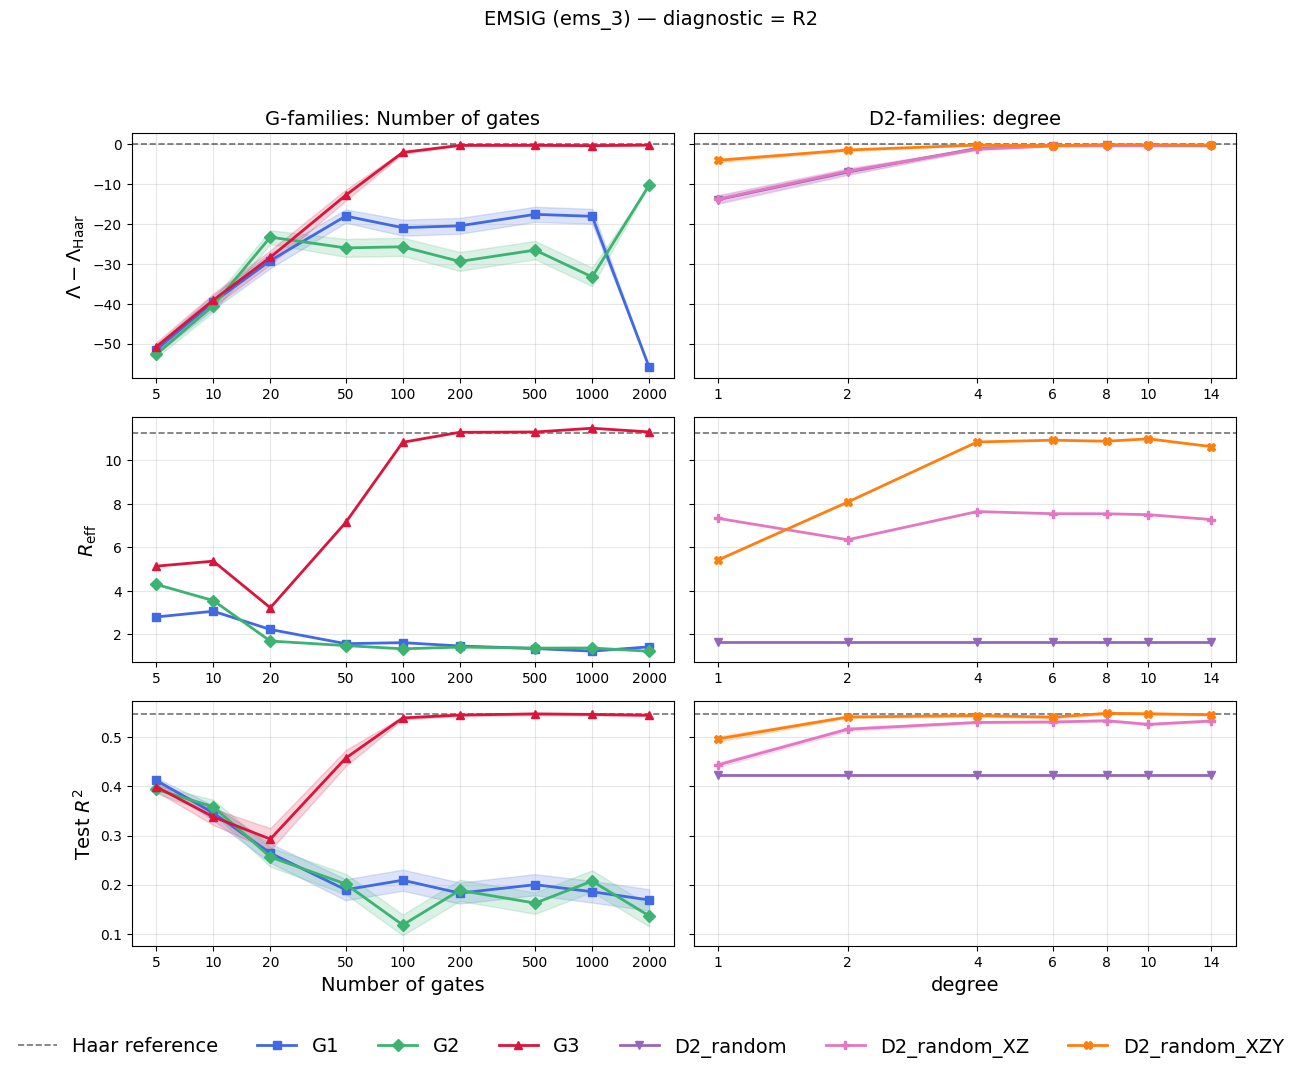

In [34]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, NullLocator

ors_Haar = np.load('results/ors/Haar_100runs.npz')
ors_Haar6 = ors_Haar['lambda_haar_n6'][1]

# ─────────────────────────────────────────────────────────────────────
# Style
# ─────────────────────────────────────────────────────────────────────
FAMILY_COLORS = {
    'Haar':          '#000000',
    'G1':            'royalblue',
    'G2':            'mediumseagreen',
    'G3':            'crimson',
    'D2_random':     '#9467bd',
    'D2_random_XZ':  '#e377c2',
    'D2_random_XZY': 'tab:orange',
}
FAMILY_MARKERS = {
    'Haar': 'o', 'G1': 's', 'G2': 'D', 'G3': '^',
    'D2_random': 'v', 'D2_random_XZ': 'P', 'D2_random_XZY': 'X',
}

ORS_LOWER_CAP = -254.0
USE_LOG_MSE   = (METRIC != 'r2')             # log scale unless R²


# ─────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────
def _scalar_stats(res, key, clip_low=None):
    if key not in res:
        return np.nan, np.nan
    vals = np.asarray(res[key], dtype=float)
    if vals.ndim == 2:
        vals = vals[:, -1]
    if clip_low is not None:
        vals = np.clip(vals, clip_low, None)
    n = len(vals)
    return float(np.mean(vals)), float(np.std(vals) / np.sqrt(n)) if n > 1 else 0.0


def _haar_scalar(metric_key, clip_low=None):
    if results_Haar is None:
        return None
    if metric_key == 'R_eff':
        return results_Haar['R_eff']
    m, _ = _scalar_stats(results_Haar, metric_key, clip_low=clip_low)
    return m


def _collect(results_dict_for_family):
    cs = sorted(results_dict_for_family.keys())
    ors_m, ors_s, reff, mse_m, mse_s = [], [], [], [], []
    for c in cs:
        r = results_dict_for_family[c]
        m, s = _scalar_stats(r, 'ors', clip_low=ORS_LOWER_CAP)
        ors_m.append(m); ors_s.append(s)
        reff.append(r['R_eff'])
        m, s = _scalar_stats(r, 'mse')             # 'mse' key = chosen metric
        mse_m.append(m); mse_s.append(s)
    return (np.array(cs), np.array(ors_m), np.array(ors_s),
            np.array(reff), np.array(mse_m), np.array(mse_s))


# ─────────────────────────────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────────────────────────────
def fig2_emsig(save_path=f'figures/exp5_emsig_{METRIC}.png'):
    fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey='row')

    g_target = ['G1', 'G2', 'G3']
    g_data   = {fam: _collect(results_g[fam]) for fam in g_target
                if len(results_g[fam]) > 0}
    d2_data  = {
        'D2_random':     _collect(results_degree),
        'D2_random_XZ':  _collect(results_degree_XZ),
        'D2_random_XZY': _collect(results_degree_XZY),
    }
    d2_data = {k: v for k, v in d2_data.items() if len(v[0]) > 0}

    plot_metrics = [
        ('ors',   r'$\Lambda - \Lambda_{\rm Haar}$'),
        ('R_eff', r'$R_{\rm eff}$'),
        ('mse',   METRIC_NAME),
    ]

    for row, (key, ylabel) in enumerate(plot_metrics):
        for col in range(2):
            ax = axes[row, col]

            clip_low = ORS_LOWER_CAP if key == 'ors' else None
            href = _haar_scalar(key, clip_low=clip_low) if key!='ors' else 0
            if href is not None and not np.isnan(href):
                ax.axhline(href, color=FAMILY_COLORS['Haar'],
                           ls='--', alpha=0.55, lw=1.2,
                           label='Haar reference' if (row == 0 and col == 0) else None)

            families = list(g_data.keys()) if col == 0 else list(d2_data.keys())
            data_src = g_data              if col == 0 else d2_data

            cs_max = None
            for family in families:
                color  = FAMILY_COLORS.get(family, '#888')
                marker = FAMILY_MARKERS.get(family, 'o')
                cs, ors_m, ors_s, reff, mse_m, mse_s = data_src[family]
                if len(cs) == 0:
                    continue
                cs_max = cs

                if key == 'ors':
                    ors_m = ors_m - ors_Haar6
                    ax.plot(cs, ors_m, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                    ax.fill_between(cs, ors_m - ors_s, ors_m + ors_s,
                                    color=color, alpha=0.18)
                elif key == 'R_eff':
                    ax.plot(cs, reff, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                else:
                    ax.plot(cs, mse_m, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                    ax.fill_between(cs, mse_m - mse_s, mse_m + mse_s,
                                    color=color, alpha=0.18)

            ax.set_xscale('log')
            if key == 'mse' and USE_LOG_MSE:
                ax.set_yscale('log')
            ax.grid(True, which='both', alpha=0.3)

            if cs_max is not None:
                ax.set_xticks(cs_max)
                ax.get_xaxis().set_major_formatter(ScalarFormatter())
                ax.get_xaxis().set_minor_locator(NullLocator())

            if row == 0:
                ax.set_title('G-families: Number of gates' if col == 0
                             else 'D2-families: degree', fontsize=14)
            if row == 2:
                ax.set_xlabel('Number of gates' if col == 0 else 'degree',
                              fontsize=14)
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=14)

    handles, labels = [], []
    for ax in axes[0]:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh); labels.append(ll)
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, -0.01), ncol=len(labels),
               fontsize=14, frameon=False)

    fig.suptitle(f'EMSIG ({EMS}) — diagnostic = {METRIC.upper()}',
                 fontsize=14, y=1.00)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()


fig2_emsig()

## Part 3: QRC on Weather Data

Repeat the full QRC sweep on the **Delhi daily weather dataset** (temperature, humidity, wind speed, pressure → next-day temperature).

This is the most important real-data validation: a multi-circuit-family sweep with `ns=100` independent reservoir instances per configuration, enabling reliable performance estimates with error bars.

In [35]:
import pandas as pd
from QRC import QuantumRC_Circuit
from sklearn.metrics import mean_absolute_error

data_train = pd.read_csv('data/time_series/weather_train.csv')
data_test = pd.read_csv('data/time_series/weather_test.csv')
data = pd.concat([data_train, data_test], ignore_index=True)

print(f"Train shape: {data_train.shape}, Test shape: {data_test.shape}, Total shape: {data.shape}")
data.head()

Train shape: (1462, 5), Test shape: (114, 5), Total shape: (1576, 5)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [36]:
y = data[['meantemp']]
cols_pred = y.shape[1]
cols = ['humidity','wind_speed', 'meanpressure']
X = data[cols].shift(1).fillna(method='bfill')

data.date = pd.to_datetime(data.date)
dateIn_val = np.datetime64("2015-09-28")
dateFin_val = np.datetime64("2016-07-24")

X_train = X[data.date<=dateIn_val]
X_val = X[(data.date>dateIn_val) & (data.date<dateFin_val)]
X_test = X[data.date>dateFin_val]

y_train = y[data.date<=dateIn_val].values
y_val = y[(data.date>dateIn_val) & (data.date<dateFin_val)].values
y_test = y[data.date>dateFin_val].values

date_train = data.date[data.date<=dateIn_val]
date_val = data.date[(data.date>dateIn_val) & (data.date<dateFin_val)]
date_test = data.date[data.date>dateFin_val]

scaler_x = MinMaxScaler(feature_range=(-1,1))

# Fit scaler with train data
X_train_scaled = scaler_x.fit_transform(X_train)
# Transform validation data
X_val_scaled = scaler_x.transform(X_val)
X_test_scaled = scaler_x.transform(X_test)

scaler_y = MinMaxScaler(feature_range=(0,1))
# Fit scaler with train data
y_train_scaled = scaler_y.fit_transform(np.array(y_train).reshape(-1,cols_pred))

# Transform validation data
y_val_scaled = scaler_y.transform(np.array(y_val).reshape(-1,cols_pred))
y_test_scaled = scaler_y.transform(np.array(y_test).reshape(-1,cols_pred))
y_val_scaled = np.clip(y_val_scaled, 0, 1)
y_test_scaled = np.clip(y_test_scaled, 0, 1)
print(f"X_train shape: {X_train_scaled.shape}, y_train shape: {y_train_scaled.shape}")
print(f"X_val shape: {X_val_scaled.shape}, y_val shape: {y_val_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}, y_test shape: {y_test_scaled.shape}")

X_train shape: (1001, 3), y_train shape: (1001, 1)
X_val shape: (299, 3), y_val shape: (299, 1)
X_test shape: (275, 3), y_test shape: (275, 1)


### Single QRC Weather Run

A single QRC instance on the weather data establishes a baseline and verifies the pipeline end-to-end before the systematic sweep. Plots show train, validation, and test predictions vs real temperature.

In [104]:
# ── QRC ───────────────────────────────────────────────────────────────────────
t_dismiss = 100
qrc = QuantumRC_Circuit(nqbits=4, k_exp = 1, encoding='pauli', num_gates=200, gates_set='G3', dim_y=1, input_mode = 'autoregressive',
                alpha=1e-10, Nv=2, t_dismiss=t_dismiss, n_measure=3)

y_train_pred_qrc = qrc.train(y = y_train_scaled, scaler = scaler_y,
                              X_train_scaled=X_train_scaled) 
y_val_pred_qrc   = qrc.test(y = y_val_scaled, scaler = scaler_y,
                             X_test_scaled=X_val_scaled,  retrain=True)
y_test_pred_qrc  = qrc.test(y = y_test_scaled, scaler = scaler_y,
                             X_test_scaled=X_test_scaled, retrain=True)


In [105]:
# QRC skips the first training sample (step 0), so compare against y_train[1:].
train_mae_qrc = mean_absolute_error(y_train[(t_dismiss):], y_train_pred_qrc)
val_mae_qrc   = mean_absolute_error(y_val,       y_val_pred_qrc)
test_mae_qrc  = mean_absolute_error(y_test,      y_test_pred_qrc)

print("── QRC ─────────────────────────────────────────────────────────────────────")
print(f"  Train — MAE: {train_mae_qrc:.3f}")
print(f"  Val   — MAE: {val_mae_qrc:.3f}  ")
print(f"  Test  — MAE: {test_mae_qrc:.3f} ")

── QRC ─────────────────────────────────────────────────────────────────────
  Train — MAE: 6.049
  Val   — MAE: 5.442  
  Test  — MAE: 5.576 


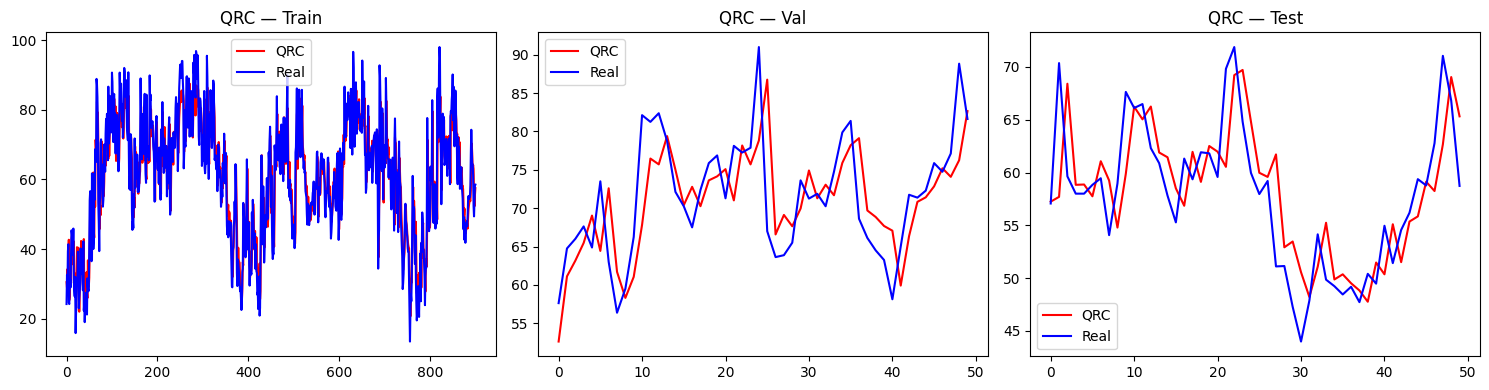

In [106]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.plot(y_train_pred_qrc[:,0], color='red',  label='QRC')
ax1.plot(y_train[t_dismiss:,0],      color='blue', label='Real')
ax1.set_title('QRC — Train'); ax1.legend()

ax2.plot(y_val_pred_qrc[:,0][50:100], color='red',  label='QRC')
ax2.plot(y_val[:,0][50:100],          color='blue', label='Real')
ax2.set_title('QRC — Val'); ax2.legend()

ax3.plot(y_test_pred_qrc[:,0][50:100], color='red',  label='QRC')
ax3.plot(y_test[:,0][50:100],          color='blue', label='Real')
ax3.set_title('QRC — Test'); ax3.legend()

plt.tight_layout(); plt.show()

## QRC Weather Sweep Results — All Families

Load the pre-computed QRC results for the weather task. The same families and gate-count ranges as the NARMA benchmark are covered, allowing cross-task comparison of which reservoir properties drive performance.

In [39]:
QRC_DIR  = os.path.join("results", "time_series", "weather")
nqbits = 4
ns = 100

# ── Persistence helpers ───────────────────────────────────────────────────────
def _qrc_path(family_gates, num_gates=-1, degree=-1.0,
              n_layers=-1, scrambler_depth=-1):
    return os.path.join(QRC_DIR,f'results_{family_gates}_{num_gates}_{degree}_{scrambler_depth}_{n_layers}.npz')

def _load_qrc(path):
    d = np.load(path, allow_pickle=True)
    return {
        'y_train_pred': d['y_train_pred'],
        'y_val_pred':   d['y_val_pred'],
        'y_test_pred':  d['y_test_pred'],
        'metrics':      d['metrics'],
        'X_train':      d['X_train'],
        'var_x':         d['var_x'],
        'ors':           d['ors'],
    }


In [40]:
# ── Haar ─────────────────────────────────
path = _qrc_path("Haar")
print(f"Loading Haar  ← {path}")
y_train_pred, y_val_pred, y_test_pred, metrics, X_train, var_x, ors = _load_qrc(path).values()
results_Haar = {"X_train": X_train, "y_train_pred": y_train_pred, "y_val_pred": y_val_pred, "y_test_pred": y_test_pred, 
                "mse": metrics[:,2], "var_x": var_x, "ors": ors}
print(f"  MSE = {np.mean(metrics[:, 2]):.8f} ± {np.std(metrics[:, 2]):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

# ── G1/G2/G3: sweep number of gates ─────────────────────────────────
g_depths       = [5,10,20,50,100,200,500,1000,2000]
g_families     = ['G1', 'G2', 'G3']
results_g      = {f: {} for f in g_families}

for family in g_families:
    for depth in depths:
        path = _qrc_path(family, num_gates=depth)
        print(f"Loading {family} ng={depth}  ← {path}")
        y_train_pred, y_val_pred, y_test_pred, metrics, X_train, var_x, ors = _load_qrc(path).values()
        results_g[family][depth] = {"X_train": X_train, "y_train_pred": y_train_pred, "y_val_pred": y_val_pred, "y_test_pred": y_test_pred, 
                "mse": metrics[:,2], "var_x": var_x, "ors": ors}
        print(f"  MSE = {np.mean(metrics[:, 2]):.8f} ± {np.std(metrics[:, 2]):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

# ── D2_random: sweep Erdős–Rényi expected degree ─────────────────────────────
degrees        = [1, 2, 4, 6, 8, 10, 14]
results_degree = {}

for deg in degrees:
    path = _qrc_path('D2_random', degree=float(deg))
    print(f"Loading D2_random deg={deg}  ← {path}")
    y_train_pred, y_val_pred, y_test_pred, metrics, X_train, var_x, ors = _load_qrc(path).values()
    results_degree[deg] = {"X_train": X_train, "y_train_pred": y_train_pred, "y_val_pred": y_val_pred, "y_test_pred": y_test_pred, 
                "mse": metrics[:,2], "var_x": var_x, "ors": ors}
    print(f"  MSE = {np.mean(metrics[:, 2]):.8f} ± {np.std(metrics[:, 2]):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

# ── D2_random_XZ: sweep Erdős–Rényi expected degree ─────────────────────────────
degrees        = [1, 2, 4, 6, 8, 10, 14]
results_degree_XZ = {}

for deg in degrees:
    path = _qrc_path('D2_random_XZ', degree=float(deg))
    print(f"Loading D2_random_XZ deg={deg}  ← {path}")
    y_train_pred, y_val_pred, y_test_pred, metrics, X_train, var_x, ors = _load_qrc(path).values()
    results_degree_XZ[deg] = {"X_train": X_train, "y_train_pred": y_train_pred, "y_val_pred": y_val_pred, "y_test_pred": y_test_pred, 
                "mse": metrics[:,2], "var_x": var_x, "ors": ors}
    print(f"  MSE = {np.mean(metrics[:, 2]):.8f} ± {np.std(metrics[:, 2]):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")

# ── D2_random_XZ: sweep Erdős–Rényi expected degree ─────────────────────────────
degrees        = [1, 2, 4, 6, 8, 10, 14]
results_degree_XZY = {}

for deg in degrees:
    path = _qrc_path('D2_random_XZY', degree=float(deg))
    print(f"Loading D2_random_XZY deg={deg}  ← {path}")
    y_train_pred, y_val_pred, y_test_pred, metrics, X_train, var_x, ors = _load_qrc(path).values()
    results_degree_XZY[deg] = {"X_train": X_train, "y_train_pred": y_train_pred, "y_val_pred": y_val_pred, "y_test_pred": y_test_pred, 
                "mse": metrics[:,2], "var_x": var_x, "ors": ors}
    print(f"  MSE = {np.mean(metrics[:, 2]):.8f} ± {np.std(metrics[:, 2]):.8f}, ORS = {np.mean(ors):.4f} ± {np.std(ors):.4f}, ΔS = {np.mean(delta_s):.4f} ± {np.std(delta_s):.4f}, Var(X) = {np.mean(var_x):.4f} ± {np.std(var_x):.4f}")


Loading Haar  ← results\time_series\weather\results_Haar_-1_-1.0_-1_-1.npz
  MSE = 1.21568311 ± 0.02040713, ORS = 9.3325 ± 0.0000, ΔS = -0.0051 ± 0.0222, Var(X) = 0.5856 ± 2.4315
Loading G1 ng=5  ← results\time_series\weather\results_G1_5_-1.0_-1_-1.npz
  MSE = 1.45482679 ± 0.97417639, ORS = -42.3952 ± 11.9107, ΔS = -0.0051 ± 0.0222, Var(X) = 0.6553 ± 2.4225
Loading G1 ng=10  ← results\time_series\weather\results_G1_10_-1.0_-1_-1.npz
  MSE = 2.02954196 ± 1.59673245, ORS = -30.4846 ± 17.9260, ΔS = -0.0051 ± 0.0222, Var(X) = 0.6562 ± 2.4229
Loading G1 ng=50  ← results\time_series\weather\results_G1_50_-1.0_-1_-1.npz
  MSE = 4.87166989 ± 1.36736935, ORS = -8.9237 ± 16.5713, ΔS = -0.0051 ± 0.0222, Var(X) = 0.5885 ± 2.4323
Loading G1 ng=100  ← results\time_series\weather\results_G1_100_-1.0_-1_-1.npz
  MSE = 5.34591519 ± 0.58179795, ORS = -11.8320 ± 20.0215, ΔS = -0.0051 ± 0.0222, Var(X) = 0.5764 ± 2.4337
Loading G1 ng=500  ← results\time_series\weather\results_G1_500_-1.0_-1_-1.npz
  MSE =

Haar R_eff = 1.13
G1: R_eff = ['1.32', '1.34', '1.15', '1.11', '1.11', '1.11']
G2: R_eff = ['1.42', '1.38', '1.13', '1.11', '1.11', '1.11']
G3: R_eff = ['1.47', '1.50', '1.14', '1.13', '1.13', '1.13']
D2_random: R_eff = ['1.30', '1.30', '1.30', '1.30', '1.30', '1.30', '1.30']
D2_random_XZ: R_eff = ['1.30', '1.30', '1.30', '1.30', '1.30', '1.30', '1.30']
D2_random_XZY: R_eff = ['1.30', '1.30', '1.30', '1.30', '1.30', '1.30', '1.30']


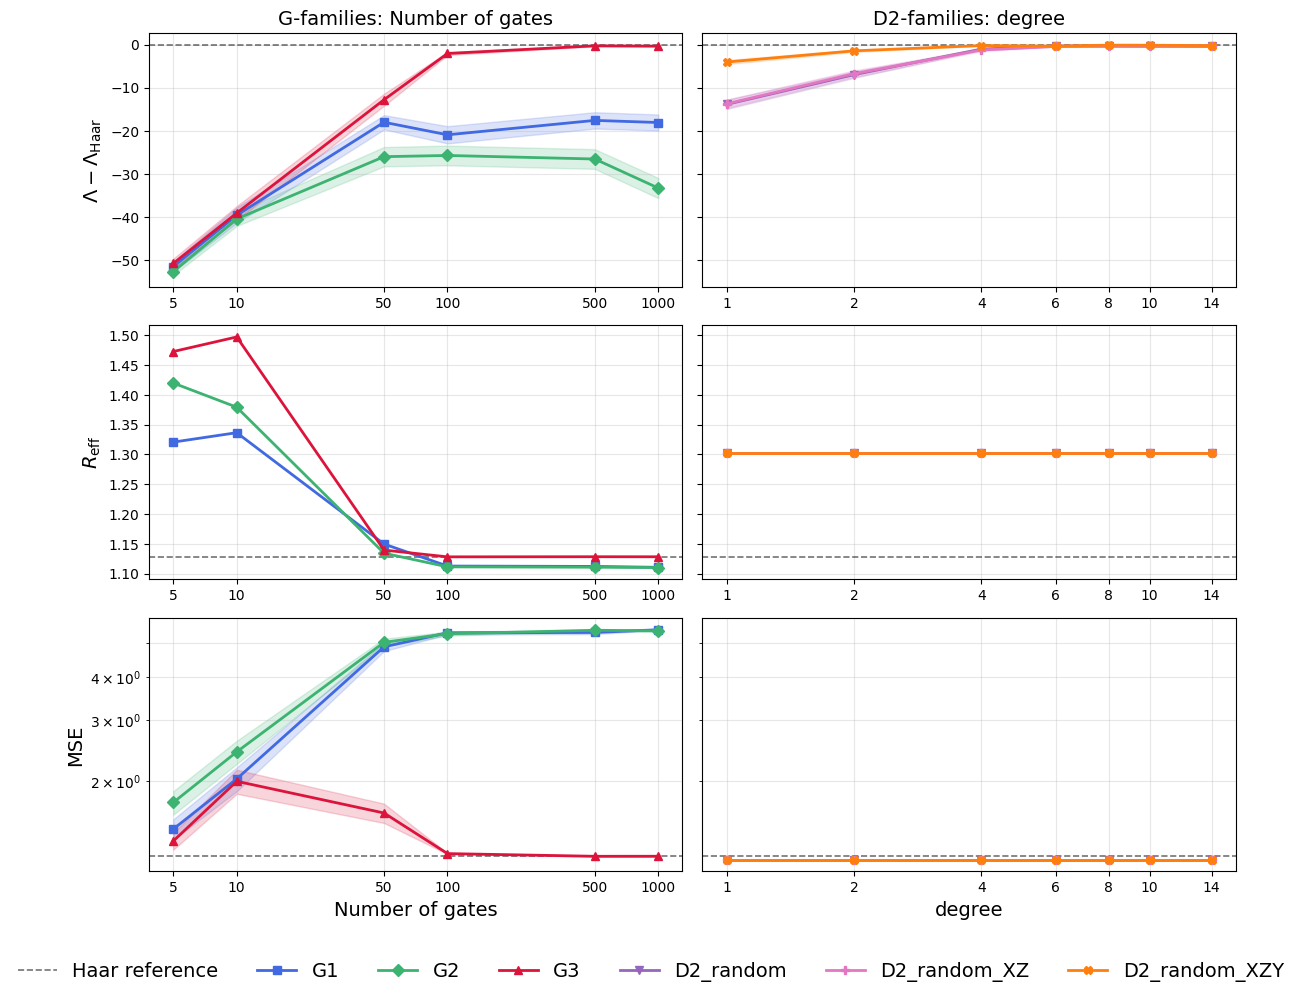

In [42]:
from matplotlib.ticker import ScalarFormatter, NullLocator

ors_Haar = np.load('results/ors/Haar_100runs.npz')
ors_Haar6 = ors_Haar['lambda_haar_n6'][1]

# ─────────────────────────────────────────────────────────────────────
# CELL A — R_eff helper, applied to X_train
# ─────────────────────────────────────────────────────────────────────
def effective_rank(F, eps=1e-12):
    """Participation ratio of singular values of the centred feature matrix."""
    F = F - F.mean(axis=0, keepdims=True)
    try:
        sv = np.linalg.svd(F, compute_uv=False)
    except np.linalg.LinAlgError:
        from scipy.linalg import svd
        sv = svd(F, compute_uv=False, lapack_driver='gesvd')
    sv = sv[sv > eps]
    if len(sv) == 0:
        return 0.0
    return float(sv.sum() ** 2 / (sv ** 2).sum())


def add_R_eff(res):
    """
    Compute R_eff from X_train. X_train may have shape (ns, T, n_obs)
    (per-sample reservoir trajectories) or (T, n_obs). We average R_eff
    over samples if the leading axis is a seed dimension.
    """
    if 'R_eff' in res:
        return res
    X = np.asarray(res['X_train'])
    if X.ndim == 3:
        reffs = [effective_rank(X[i]) for i in range(X.shape[0])]
        res['R_eff']     = float(np.mean(reffs))
        res['R_eff_sem'] = float(np.std(reffs) / np.sqrt(len(reffs))) if len(reffs) > 1 else 0.0
    else:
        res['R_eff']     = effective_rank(X)
        res['R_eff_sem'] = 0.0
    return res


# Augment all loaded dicts
add_R_eff(results_Haar)
for family in g_families:
    for depth in results_g[family]:
        add_R_eff(results_g[family][depth])
for deg in results_degree:
    add_R_eff(results_degree[deg])
for deg in results_degree_XZ:
    add_R_eff(results_degree_XZ[deg])
for deg in results_degree_XZY:
    add_R_eff(results_degree_XZY[deg])

print(f"Haar R_eff = {results_Haar['R_eff']:.2f}")
for family in g_families:
    rs = [results_g[family][d]['R_eff'] for d in sorted(results_g[family])]
    print(f"{family}: R_eff = {[f'{r:.2f}' for r in rs]}")
for name, dct in [('D2_random', results_degree),
                  ('D2_random_XZ', results_degree_XZ),
                  ('D2_random_XZY', results_degree_XZY)]:
    rs = [dct[d]['R_eff'] for d in sorted(dct)]
    print(f"{name}: R_eff = {[f'{r:.2f}' for r in rs]}")


# ─────────────────────────────────────────────────────────────────────
# Style
# ─────────────────────────────────────────────────────────────────────
FAMILY_COLORS = {
    'Haar':          '#000000',
    'G1':            'royalblue',
    'G2':            'mediumseagreen',
    'G3':            'crimson',
    'D2_random':     '#9467bd',
    'D2_random_XZ':  '#e377c2',
    'D2_random_XZY': 'tab:orange',
}
FAMILY_MARKERS = {
    'Haar': 'o', 'G1': 's', 'G2': 'D', 'G3': '^',
    'D2_random': 'v', 'D2_random_XZ': 'P', 'D2_random_XZY': 'X',
}

ORS_LOWER_CAP = -254.0
MSE_FLOOR     = 1e-15


# ─────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────
def _scalar_stats(res, key, clip_low=None):
    if key not in res:
        return np.nan, np.nan
    vals = np.asarray(res[key], dtype=float)
    if vals.ndim == 2:
        vals = vals[:, -1]
    if clip_low is not None:
        vals = np.clip(vals, clip_low, None)
    ns = len(vals)
    return float(np.mean(vals)), float(np.std(vals) / np.sqrt(ns)) if ns > 1 else 0.0


def _haar_scalar(metric_key, clip_low=None):
    if metric_key == 'R_eff':
        return results_Haar['R_eff']
    m, _ = _scalar_stats(results_Haar, metric_key, clip_low=clip_low)
    return m


def _collect(results_dict_for_family):
    cs = sorted(results_dict_for_family.keys())
    ors_m, ors_s, reff, mse_m, mse_s = [], [], [], [], []
    for c in cs:
        r = results_dict_for_family[c]
        m, s = _scalar_stats(r, 'ors', clip_low=ORS_LOWER_CAP)
        ors_m.append(m); ors_s.append(s)
        reff.append(r['R_eff'])
        m, s = _scalar_stats(r, 'mse', clip_low=MSE_FLOOR)
        mse_m.append(m); mse_s.append(s)
    return (np.array(cs), np.array(ors_m), np.array(ors_s),
            np.array(reff), np.array(mse_m), np.array(mse_s))


# ─────────────────────────────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────────────────────────────
def fig2_qrc(save_path='fig2_qrc.png',
             ors_cap=ORS_LOWER_CAP, mse_floor=MSE_FLOOR):

    fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey='row')

    g_target = ['G1', 'G2', 'G3']
    g_data  = {fam: _collect(results_g[fam]) for fam in g_target}
    d2_data = {
        'D2_random':     _collect(results_degree),
        'D2_random_XZ':  _collect(results_degree_XZ),
        'D2_random_XZY': _collect(results_degree_XZY),
    }

    metrics = [
        ('ors',   r'$\Lambda - \Lambda_{\rm Haar}$'),
        ('R_eff', r'$R_{\rm eff}$'),
        ('mse',   'MSE'),
    ]

    for row, (key, ylabel) in enumerate(metrics):
        for col in range(2):
            ax = axes[row, col]

            clip_low = ors_cap if key == 'ors' else (mse_floor if key == 'mse' else None)
            href = _haar_scalar(key, clip_low=clip_low) if key != 'ors' else 0
            if href is not None and not np.isnan(href):
                ax.axhline(href, color=FAMILY_COLORS['Haar'],
                           ls='--', alpha=0.55, lw=1.2,
                           label='Haar reference' if (row == 0 and col == 0) else None)

            families = g_target if col == 0 else list(d2_data.keys())
            data_src = g_data   if col == 0 else d2_data

            cs_max = None
            for family in families:
                color  = FAMILY_COLORS.get(family, '#888')
                marker = FAMILY_MARKERS.get(family, 'o')
                cs, ors_m, ors_s, reff, mse_m, mse_s = data_src[family]
                if len(cs) == 0:
                    continue
                cs_max = cs

                if key == 'ors':
                    ors_m = ors_m - ors_Haar6
                    ax.plot(cs, ors_m, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                    ax.fill_between(cs, ors_m - ors_s, ors_m + ors_s,
                                    color=color, alpha=0.18)
                elif key == 'R_eff':
                    ax.plot(cs, reff, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                else:
                    ax.plot(cs, mse_m, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                    ax.fill_between(cs, mse_m - mse_s, mse_m + mse_s,
                                    color=color, alpha=0.18)

            ax.set_xscale('log')
            if key == 'mse':
                ax.set_yscale('log')
            ax.grid(True, which='both', alpha=0.3)

            if cs_max is not None:
                ax.set_xticks(cs_max)
                ax.get_xaxis().set_major_formatter(ScalarFormatter())
                ax.get_xaxis().set_minor_locator(NullLocator())

            if row == 0:
                ax.set_title('G-families: Number of gates' if col == 0
                             else 'D2-families: degree', fontsize=14)
            if row == 2:
                ax.set_xlabel('Number of gates' if col == 0 else 'degree',
                              fontsize=14)
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=14)

    handles, labels = [], []
    for ax in axes[0]:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh); labels.append(ll)
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, -0.01), ncol=len(labels),
               fontsize=14, frameon=False)

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()


fig2_qrc()